# Logic Comparison Results

This notebook loads the compiled CSV results for logic 1, logic 2, and logic 3.
It compares cooling output, chiller and plant efficiency, electrical consumption, staging, and chilled-water control behavior.

In [1]:
from pathlib import Path
import subprocess

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "Trial_Final" / "logic1.mo").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "Trial_Final"
elif not (NOTEBOOK_DIR / "logic1.mo").exists() and "__file__" in globals():
    NOTEBOOK_DIR = Path(__file__).resolve().parent

RUNNERS = [
    NOTEBOOK_DIR / "logic 1" / "run_logic1.ps1",
    NOTEBOOK_DIR / "logic2" / "run_logic2.ps1",
    NOTEBOOK_DIR / "logic3" / "run_logic3.ps1",
]

for runner in RUNNERS:
    if not runner.exists():
        raise FileNotFoundError(f"Simulation runner not found: {runner}")
    print(f"Running {runner.parent.name}...")
    completed = subprocess.run(
        [
            "powershell.exe",
            "-NoProfile",
            "-ExecutionPolicy",
            "Bypass",
            "-File",
            str(runner),
        ],
        cwd=NOTEBOOK_DIR,
        check=False,
    )
    if completed.returncode != 0:
        raise RuntimeError(f"Simulation failed for {runner}: exit code {completed.returncode}")

print("All simulations completed and CSV files were refreshed.")

Running logic 1...
Running logic2...
Running logic3...
All simulations completed and CSV files were refreshed.


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "Trial_Final" / "logic1.mo").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "Trial_Final"
elif not (NOTEBOOK_DIR / "logic1.mo").exists() and "__file__" in globals():
    NOTEBOOK_DIR = Path(__file__).resolve().parent

RESULT_FILES = {
    "Logic 1": NOTEBOOK_DIR / "logic 1" / "logic1_results.csv",
    "Logic 2": NOTEBOOK_DIR / "logic2" / "logic2_results.csv",
    "Logic 3": NOTEBOOK_DIR / "logic3" / "logic3_results.csv",
}

COLORS = {"Logic 1": "#2563eb", "Logic 2": "#dc2626", "Logic 3": "#16a34a"}
REQUIRED_COLUMNS = [
    "timestamp",
    "time_s",
    "elapsed_minutes",
    "outdoor_temp_degC",
    "room_temperature_degC",
    "room_demand_kW",
    "room_demand_TR",
    "coil_cooling_kW",
    "coil_cooling_TR",
    "chiller_evaporator_cooling_kW",
    "chiller_evaporator_cooling_TR",
    "chiller_1_evaporator_cooling_kW",
    "chiller_1_evaporator_cooling_TR",
    "chiller_2_evaporator_cooling_kW",
    "chiller_2_evaporator_cooling_TR",
    "actual_total_chiller_cooling_kW",
    "actual_total_chiller_cooling_TR",
    "chilled_water_supply_temp_degC",
    "chilled_water_return_temp_degC",
    "chilled_water_deltaT_degC",
    "chilled_water_mass_flow_kg_s",
    "chilled_water_sensor_cooling_kW",
    "chilled_water_sensor_cooling_TR",
    "unmet_cooling_load_kW",
    "unmet_cooling_load_TR",
    "cooling_load_met_percent",
    "chiller_1_status",
    "chiller_2_status",
    "chiller_1_mass_flow_kg_s",
    "chiller_2_mass_flow_kg_s",
    "chiller_1_chwst_setpoint_degC",
    "chiller_2_chwst_setpoint_degC",
    "chiller_1_request_more_chiller",
    "chiller_2_request_more_chiller",
]
TEXT_COLUMNS = {
    "timestamp",
    "logic",
    "chiller_1_status",
    "chiller_2_status",
    "chiller_1_request_more_chiller",
    "chiller_2_request_more_chiller",
}

def flag_to_int(series):
    return series.fillna("no").astype(str).str.lower().isin(["yes", "true", "1", "on"]).astype(int)

def load_results(label, path):
    if not path.exists():
        raise FileNotFoundError(f"{label} result file not found: {path}")
    frame = pd.read_csv(path)
    frame["timestamp"] = pd.to_datetime(frame["timestamp"])
    frame["logic"] = label
    missing = sorted(set(REQUIRED_COLUMNS) - set(frame.columns))
    if missing:
        raise ValueError(f"{label} result file is missing required columns: {missing}")
    for column in frame.columns:
        if column not in TEXT_COLUMNS:
            frame[column] = pd.to_numeric(frame[column], errors="coerce")
    frame["hours"] = frame["elapsed_minutes"] / 60.0
    frame["chiller_1_on"] = frame["chiller_1_status"].fillna("off").astype(str).str.lower().eq("on").astype(int)
    frame["chiller_2_on"] = frame["chiller_2_status"].fillna("off").astype(str).str.lower().eq("on").astype(int)
    frame["active_chillers"] = frame["chiller_1_on"] + frame["chiller_2_on"]
    frame["chiller_1_request_flag"] = flag_to_int(frame["chiller_1_request_more_chiller"])
    frame["chiller_2_request_flag"] = flag_to_int(frame["chiller_2_request_more_chiller"])
    frame["chiller_1_dT_active_degC"] = frame["chiller_1_dT_degC"].where(frame["chiller_1_mass_flow_kg_s"] > 0.01)
    frame["chiller_2_dT_active_degC"] = frame["chiller_2_dT_degC"].where(frame["chiller_2_mass_flow_kg_s"] > 0.01)
    frame["auxiliary_power_kW"] = frame["water_side_total_power_kW"] - frame["chiller_total_power_kW"]
    frame["total_chiller_flow_kg_s"] = frame["chiller_1_mass_flow_kg_s"] + frame["chiller_2_mass_flow_kg_s"]
    return frame

results_by_logic = {label: load_results(label, path) for label, path in RESULT_FILES.items()}
reference_label = next(iter(results_by_logic))
reference = results_by_logic[reference_label]
for label, frame in results_by_logic.items():
    if len(frame) != len(reference):
        raise ValueError(f"{label} has {len(frame)} rows; {reference_label} has {len(reference)} rows")
    if not np.allclose(frame["time_s"], reference["time_s"], rtol=0, atol=1e-6, equal_nan=True):
        raise ValueError(f"{label} time grid does not match {reference_label}")
    if not np.allclose(frame["room_demand_kW"], reference["room_demand_kW"], rtol=0, atol=1e-6, equal_nan=True):
        raise ValueError(f"{label} room demand profile does not match {reference_label}")

results = pd.concat(results_by_logic.values(), ignore_index=True)
print(f"Loaded {len(results_by_logic)} result files with {len(reference)} aligned rows each.")

Loaded 3 result files with 2017 aligned rows each.


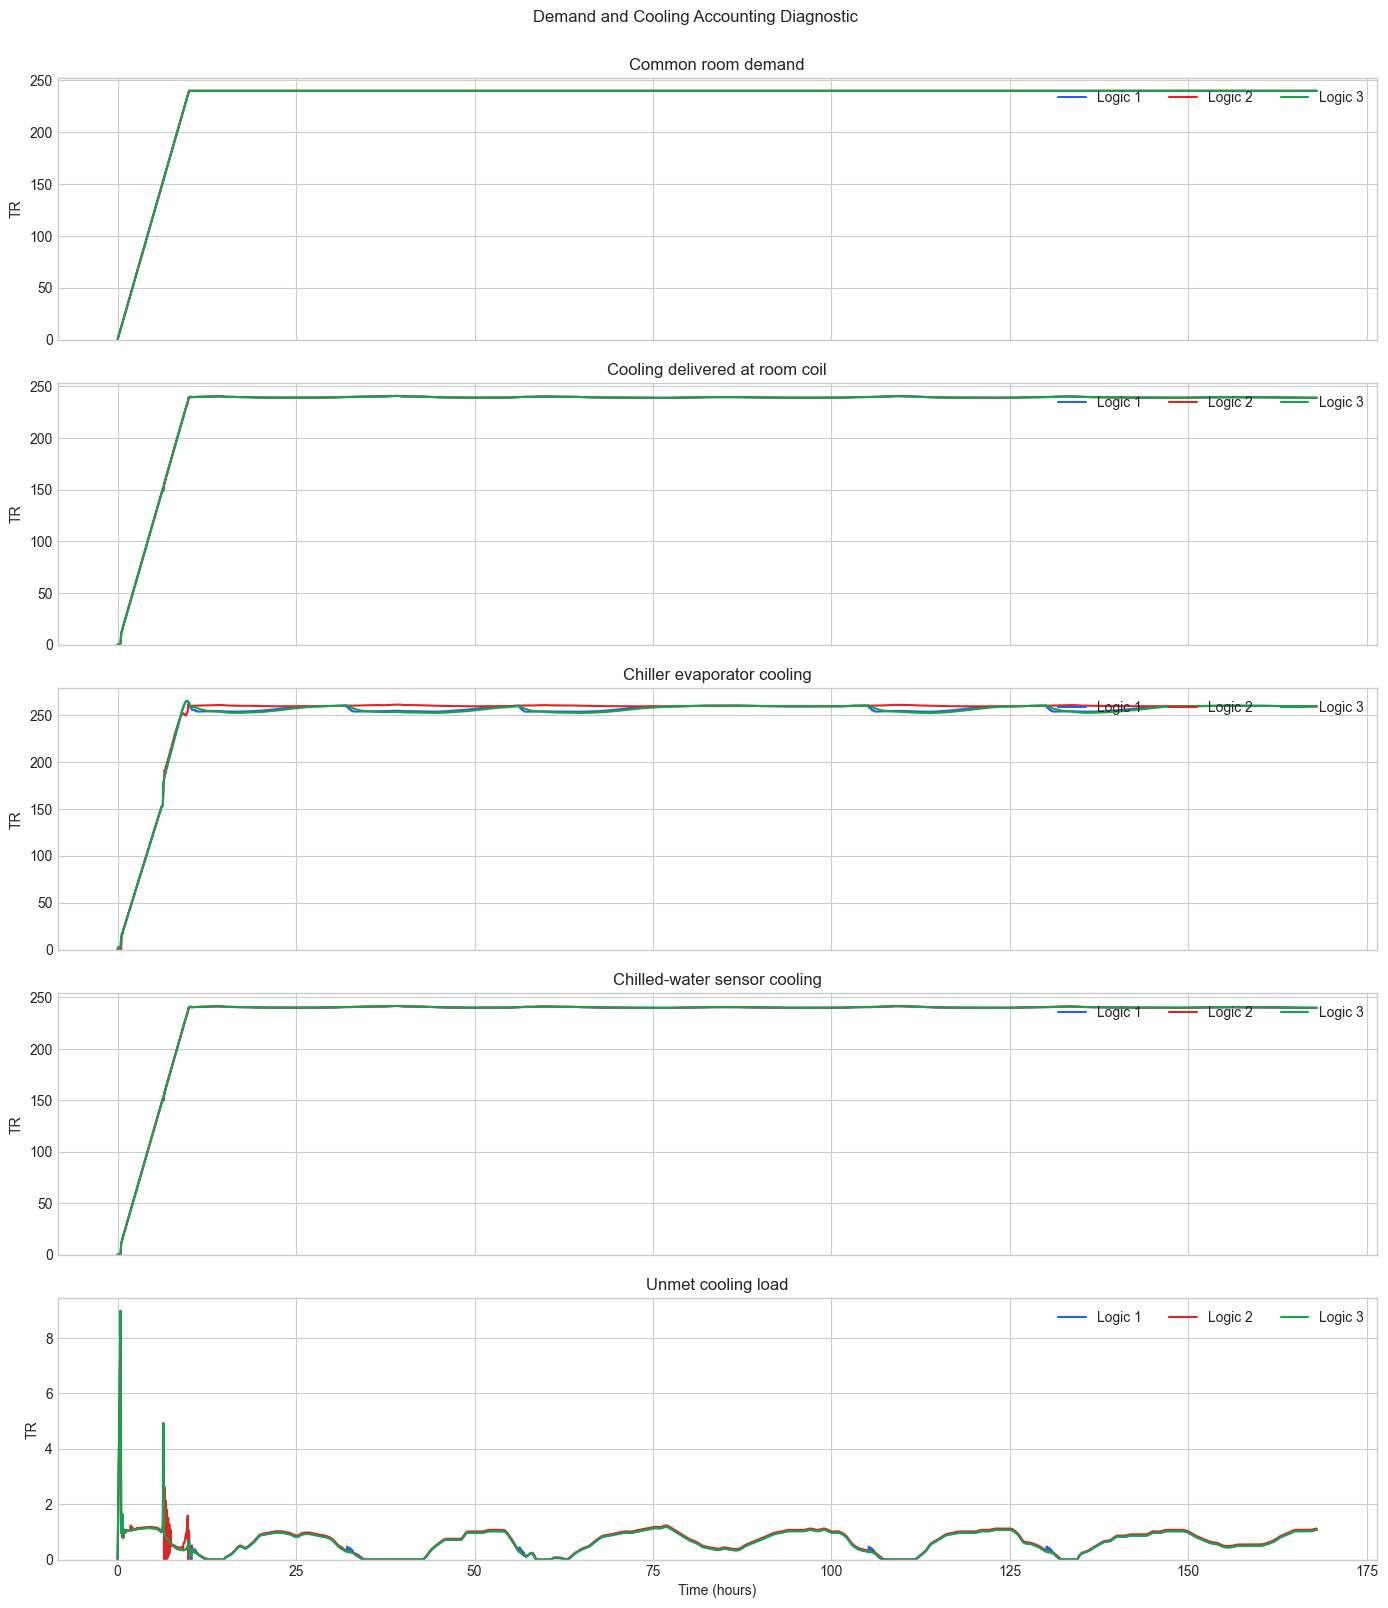

In [3]:
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
diagnostic_specs = [
    ("room_demand_TR", "Common room demand", "TR"),
    ("coil_cooling_TR", "Cooling delivered at room coil", "TR"),
    ("chiller_evaporator_cooling_TR", "Chiller evaporator cooling", "TR"),
    ("chilled_water_sensor_cooling_TR", "Chilled-water sensor cooling", "TR"),
    ("unmet_cooling_load_TR", "Unmet cooling load", "TR"),
]

for axis, (column, title, ylabel) in zip(axes, diagnostic_specs):
    for label, frame in results_by_logic.items():
        axis.plot(frame["hours"], frame[column], label=label, color=COLORS[label], linewidth=1.5)
    axis.set_ylabel(ylabel)
    axis.set_title(title)
    axis.set_ylim(bottom=0)
    axis.legend(ncol=3, loc="upper right")

axes[-1].set_xlabel("Time (hours)")
fig.suptitle("Demand and Cooling Accounting Diagnostic", y=1.002)
fig.tight_layout()
plt.show()

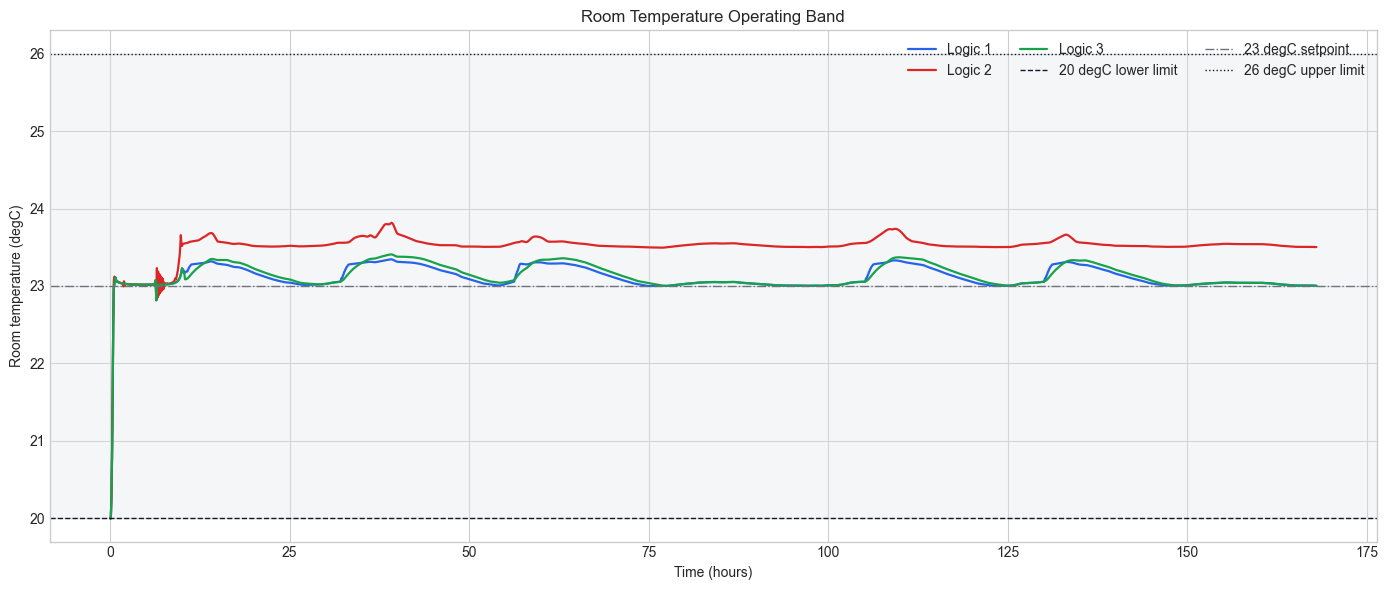

In [4]:
fig, axis = plt.subplots(figsize=(14, 6))
for label, frame in results_by_logic.items():
    axis.plot(frame["hours"], frame["room_temperature_degC"], label=label, color=COLORS[label], linewidth=1.6)

axis.axhspan(20, 26, color="#e5e7eb", alpha=0.35)
axis.axhline(20, color="#111827", linestyle="--", linewidth=1, label="20 degC lower limit")
axis.axhline(23, color="#6b7280", linestyle="-.", linewidth=1, label="23 degC setpoint")
axis.axhline(26, color="#111827", linestyle=":", linewidth=1, label="26 degC upper limit")
axis.set_xlabel("Time (hours)")
axis.set_ylabel("Room temperature (degC)")
axis.set_title("Room Temperature Operating Band")
axis.legend(ncol=3)
fig.tight_layout()
plt.show()

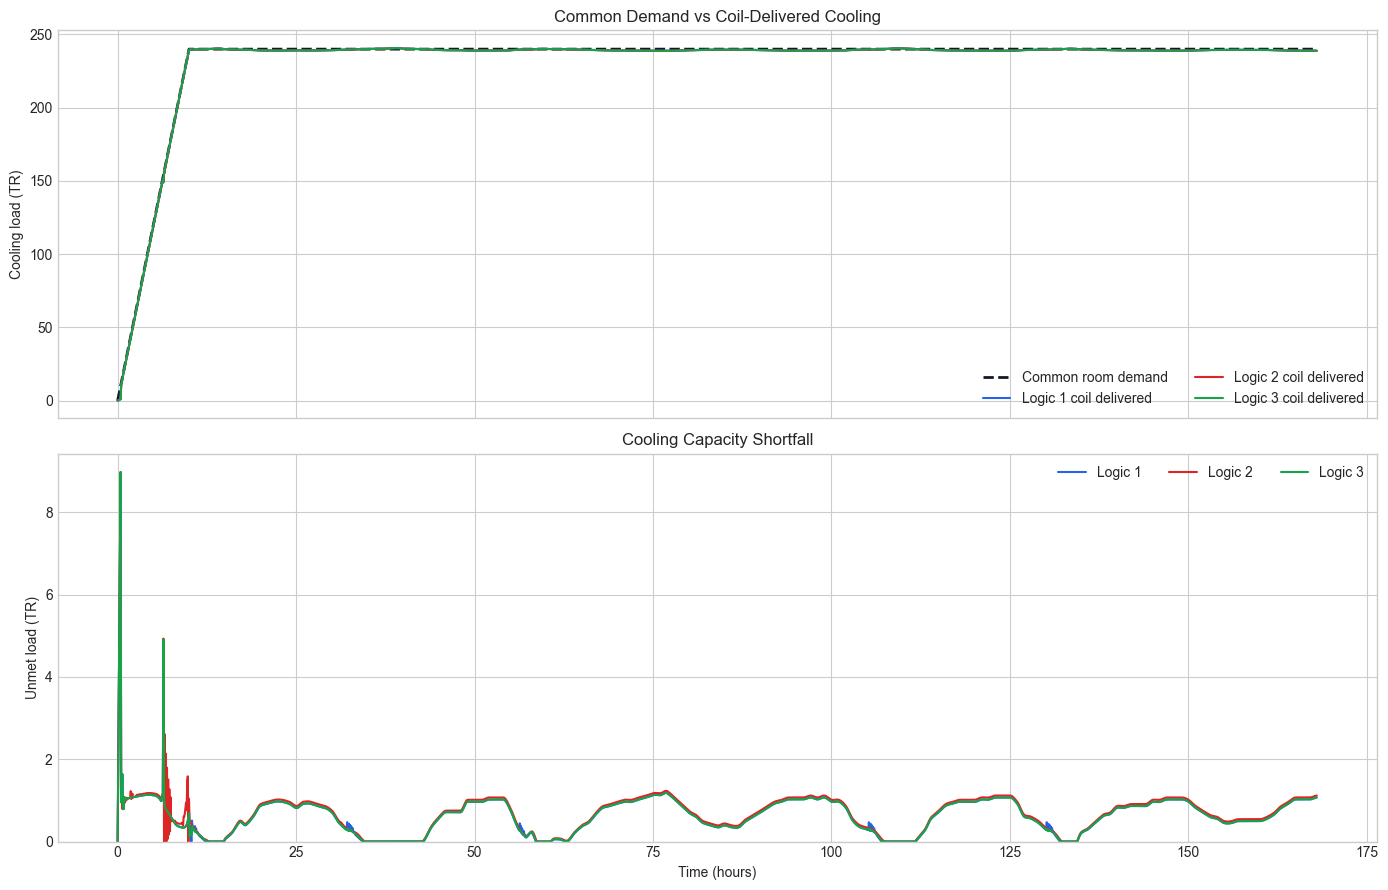

room_demand_TR          coil_cooling_TR               chiller_evaporator_cooling_TR              chilled_water_sensor_cooling_TR                \
                  mean  max min            mean      max  min                          mean     max  min                            mean      max  min   
logic                                                                                                                                                    
Logic 1        232.801  240   0         232.203  240.799  0.0                       249.640  265.07  0.0                         233.097  241.720  0.0   
Logic 2        232.801  240   0         232.162  240.751  0.0                       252.113  261.76  0.0                         233.054  241.676  0.0   
Logic 3        232.801  240   0         232.201  240.792  0.0                       249.150  265.07  0.0                         233.095  241.713  0.0   

        unmet_cooling_load_TR             cooling_load_met_percent               chiller_performance_actual_kW_per_TR               \
                         mean    max  min                     mean    max    min                                 mean    max   min   
logic                                                                                                                                
Logic 1                 0.630  8.974  0.0                   99.460  100.0  5.004                                0.561  0.662  0.39   
Logic 2                 0.669  8.974  0.0                   99.444  100.0  5.004                                0.563  0.671  0.00   
Logic 3                 0.630  8.974  0.0                   99.460  100.0  5.004                                0.561  0.659  0.39   

        plant_performance_actual_kW_per_TR               water_side_total_power_kW               auxiliary_power_kW               active_chillers          
                                      mean    max    min                      mean      max  min               mean      max  min            mean max min  
logic                                                                                                                                                      
Logic 1                              0.900  1.948  0.724                   225.264  308.591  0.0             83.954  156.600  0.0           1.961   2   0  
Logic 2                              0.933  2.533  0.696                   236.317  290.754  0.0             92.828  156.605  0.0           1.961   2   0  
Logic 3                              0.893  1.948  0.724                   223.120  308.591  0.0             82.238  156.600  0.0           1.961   2   0

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
reference_frame = results_by_logic["Logic 1"]
axes[0].plot(
    reference_frame["hours"],
    reference_frame["room_demand_TR"],
    label="Common room demand",
    color="#111827",
    linestyle="--",
    linewidth=2,
)

for label, frame in results_by_logic.items():
    axes[0].plot(frame["hours"], frame["coil_cooling_TR"], label=f"{label} coil delivered", color=COLORS[label])
    axes[1].plot(frame["hours"], frame["unmet_cooling_load_TR"], label=label, color=COLORS[label])

axes[0].set_ylabel("Cooling load (TR)")
axes[0].set_title("Common Demand vs Coil-Delivered Cooling")
axes[0].legend(ncol=2)
axes[1].set_xlabel("Time (hours)")
axes[1].set_ylabel("Unmet load (TR)")
axes[1].set_title("Cooling Capacity Shortfall")
axes[1].set_ylim(bottom=0)
axes[1].legend(ncol=3)
fig.tight_layout()
plt.show()

summary_columns = [
    "room_demand_TR",
    "coil_cooling_TR",
    "chiller_evaporator_cooling_TR",
    "chilled_water_sensor_cooling_TR",
    "unmet_cooling_load_TR",
    "cooling_load_met_percent",
    "chiller_performance_actual_kW_per_TR",
    "plant_performance_actual_kW_per_TR",
    "water_side_total_power_kW",
    "auxiliary_power_kW",
    "active_chillers",
]
summary = results.groupby("logic")[summary_columns].agg(["mean", "max", "min"]).round(3)
summary

## Efficiency and Cooling Output

The plant kW/TR line includes chiller, chilled-water pump, condenser-water pump, and cooling-tower fan power. Performance points with very low actual cooling can dominate the instantaneous ratio.

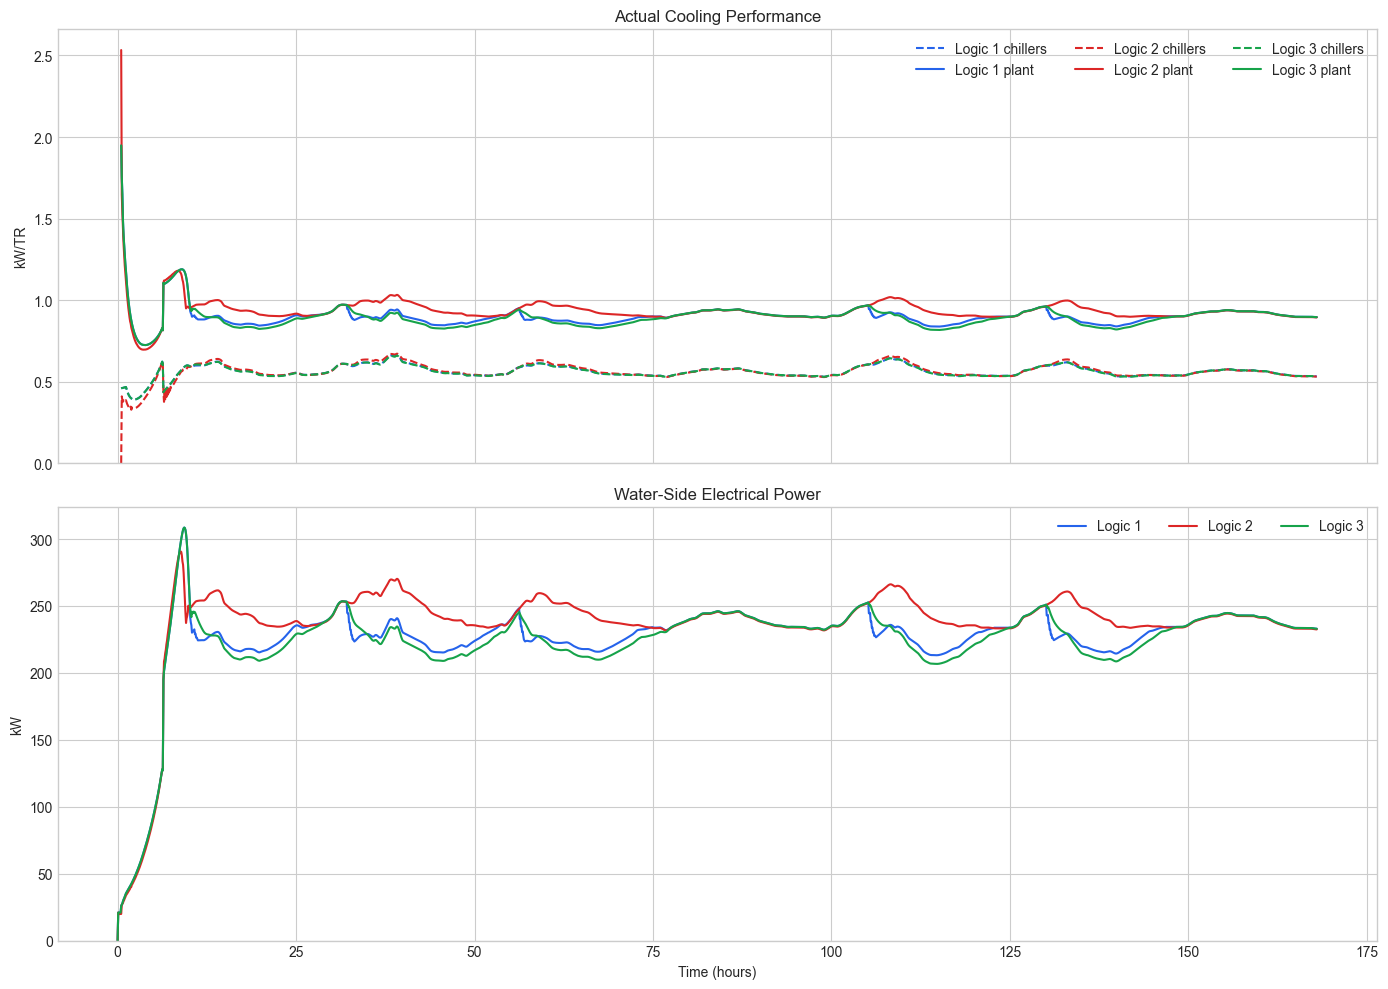

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
for label, frame in results_by_logic.items():
    axes[0].plot(frame["hours"], frame["chiller_performance_actual_kW_per_TR"], label=f"{label} chillers", color=COLORS[label], linestyle="--")
    axes[0].plot(frame["hours"], frame["plant_performance_actual_kW_per_TR"], label=f"{label} plant", color=COLORS[label])
    axes[1].plot(frame["hours"], frame["water_side_total_power_kW"], label=label, color=COLORS[label], linewidth=1.5)

axes[0].set_ylabel("kW/TR")
axes[0].set_title("Actual Cooling Performance")
axes[0].set_ylim(bottom=0)
axes[0].legend(ncol=3)
axes[1].set_xlabel("Time (hours)")
axes[1].set_ylabel("kW")
axes[1].set_title("Water-Side Electrical Power")
axes[1].set_ylim(bottom=0)
axes[1].legend(ncol=3)
fig.tight_layout()
plt.show()

## Electrical Consumption

This chart separates chiller power from auxiliary power. Auxiliary power includes all pumps and cooling-tower fans in the compiled result.

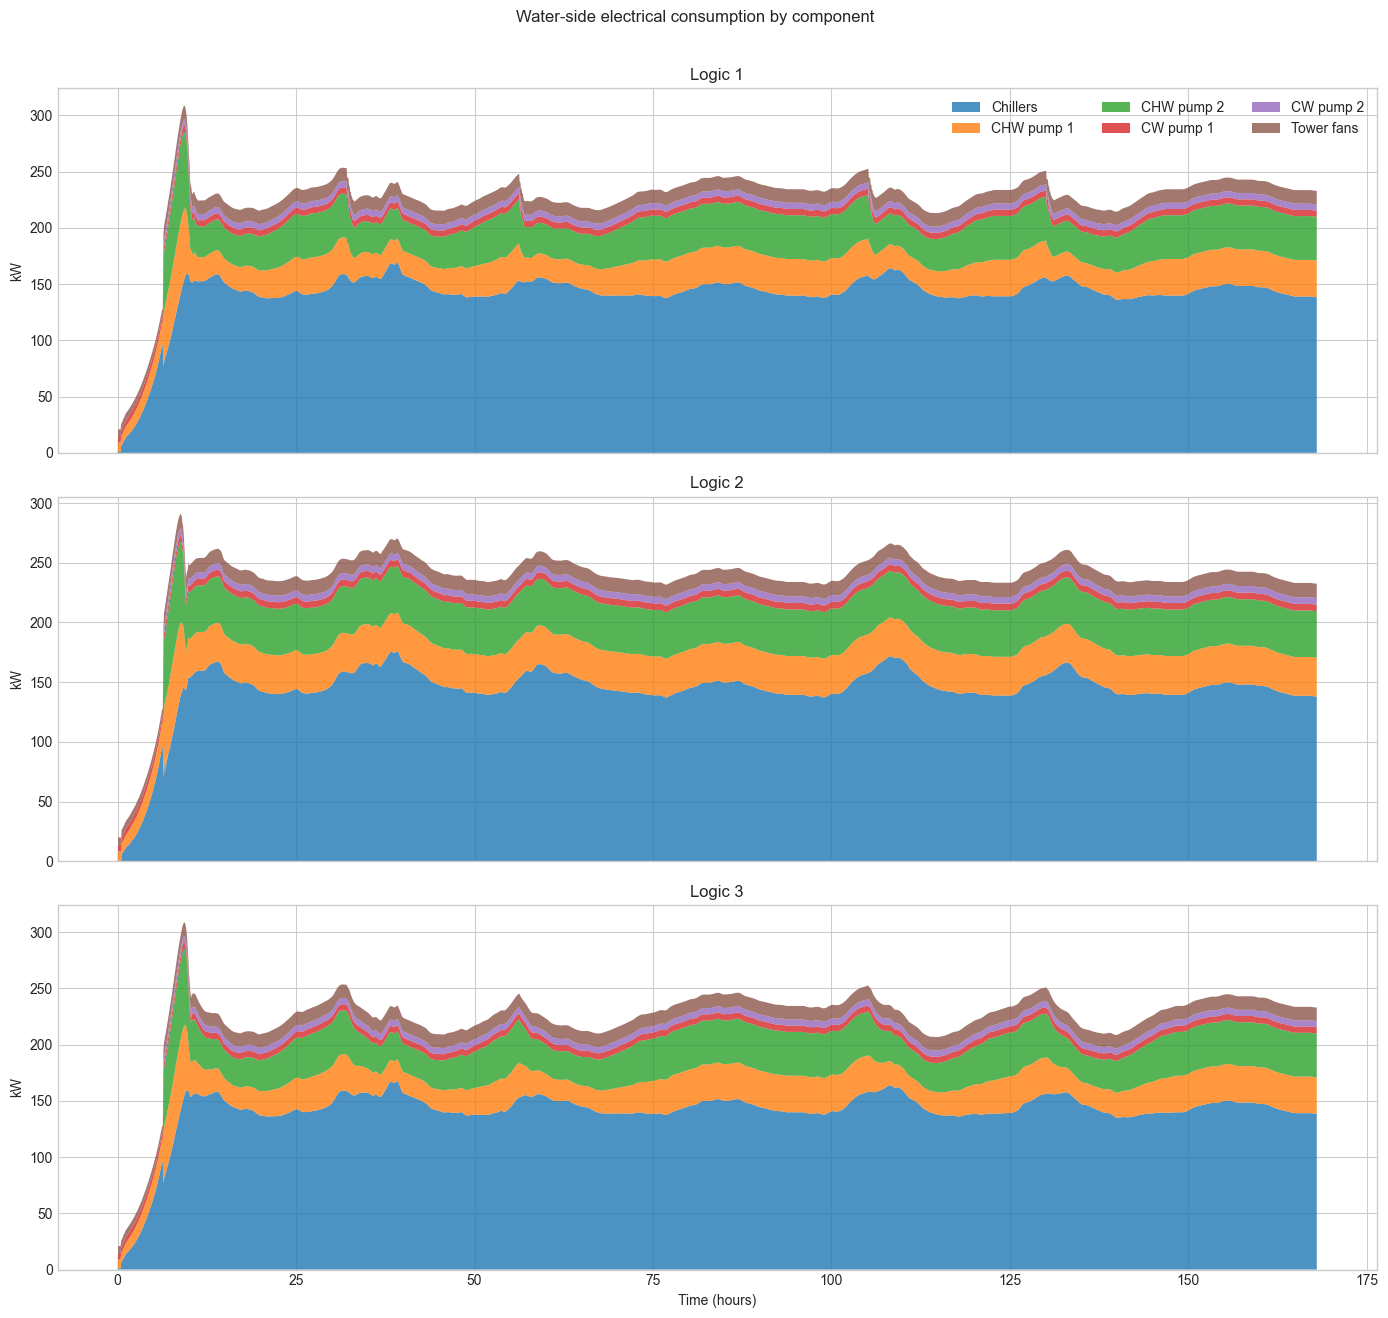

In [7]:
power_columns = [
    "chiller_total_power_kW",
    "chw_pump_1_power_kW",
    "chw_pump_2_power_kW",
    "cw_pump_1_power_kW",
    "cw_pump_2_power_kW",
    "cooling_tower_fan_total_power_kW",
]
power_labels = {
    "chiller_total_power_kW": "Chillers",
    "chw_pump_1_power_kW": "CHW pump 1",
    "chw_pump_2_power_kW": "CHW pump 2",
    "cw_pump_1_power_kW": "CW pump 1",
    "cw_pump_2_power_kW": "CW pump 2",
    "cooling_tower_fan_total_power_kW": "Tower fans",
}

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)
for axis, (label, frame) in zip(axes, results_by_logic.items()):
    hours = frame["elapsed_minutes"] / 60
    bottom = pd.Series(0.0, index=frame.index)
    for column in power_columns:
        values = frame[column].fillna(0)
        axis.fill_between(hours, bottom, bottom + values, label=power_labels[column], alpha=0.8)
        bottom = bottom + values
    axis.set_ylabel("kW")
    axis.set_title(label)
    axis.set_ylim(bottom=0)
axes[-1].set_xlabel("Time (hours)")
axes[0].legend(ncol=3, loc="upper right")
fig.suptitle("Water-side electrical consumption by component", y=1.01)
fig.tight_layout()
plt.show()

## Staging and Chilled-Water Control

Logic 1 controls flow around a 5 degC delta-T. Logic 2 resets CHWST toward a 12 degC return temperature with maximum pump flow. Logic 3 combines those actions in flow-first order.

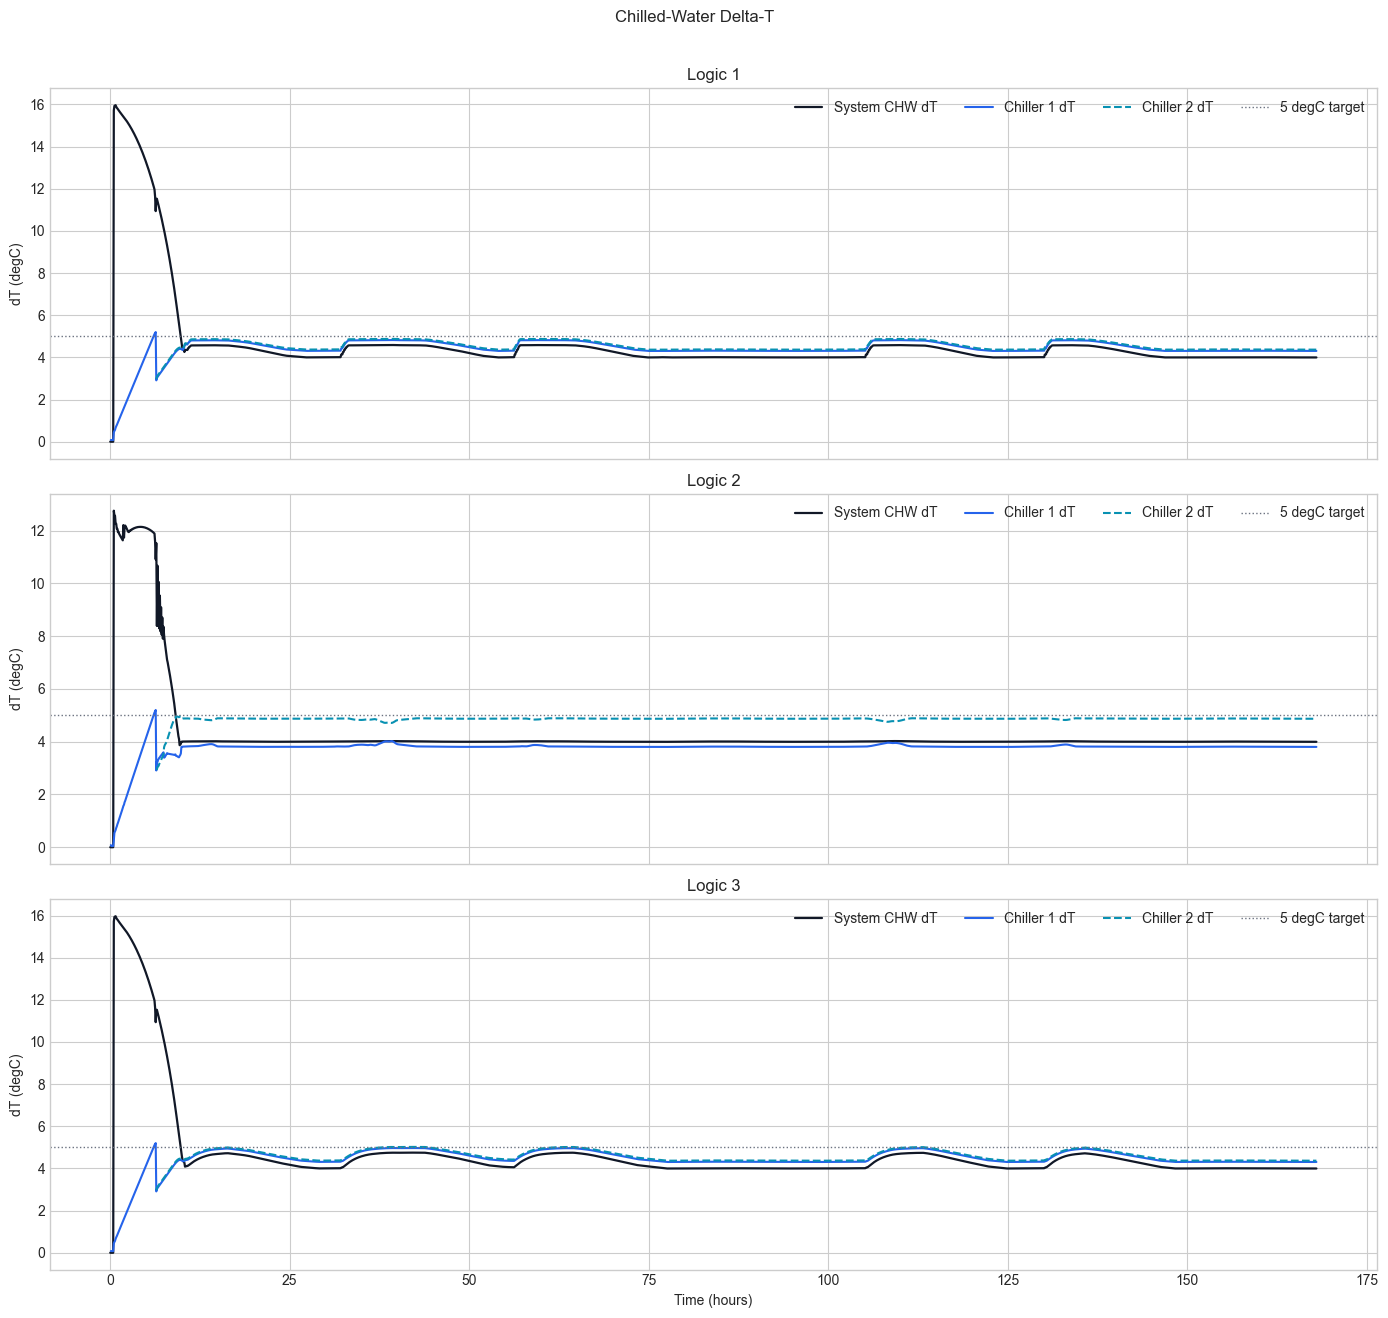

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)
for axis, (label, frame) in zip(axes, results_by_logic.items()):
    axis.plot(frame["hours"], frame["chilled_water_deltaT_degC"], label="System CHW dT", color="#111827", linewidth=1.6)
    axis.plot(frame["hours"], frame["chiller_1_dT_active_degC"], label="Chiller 1 dT", color="#2563eb")
    axis.plot(frame["hours"], frame["chiller_2_dT_active_degC"], label="Chiller 2 dT", color="#0891b2", linestyle="--")
    axis.axhline(5, color="#6b7280", linestyle=":", linewidth=1, label="5 degC target")
    axis.set_ylabel("dT (degC)")
    axis.set_title(label)
    axis.legend(ncol=4, loc="upper right")
axes[-1].set_xlabel("Time (hours)")
fig.suptitle("Chilled-Water Delta-T", y=1.01)
fig.tight_layout()
plt.show()

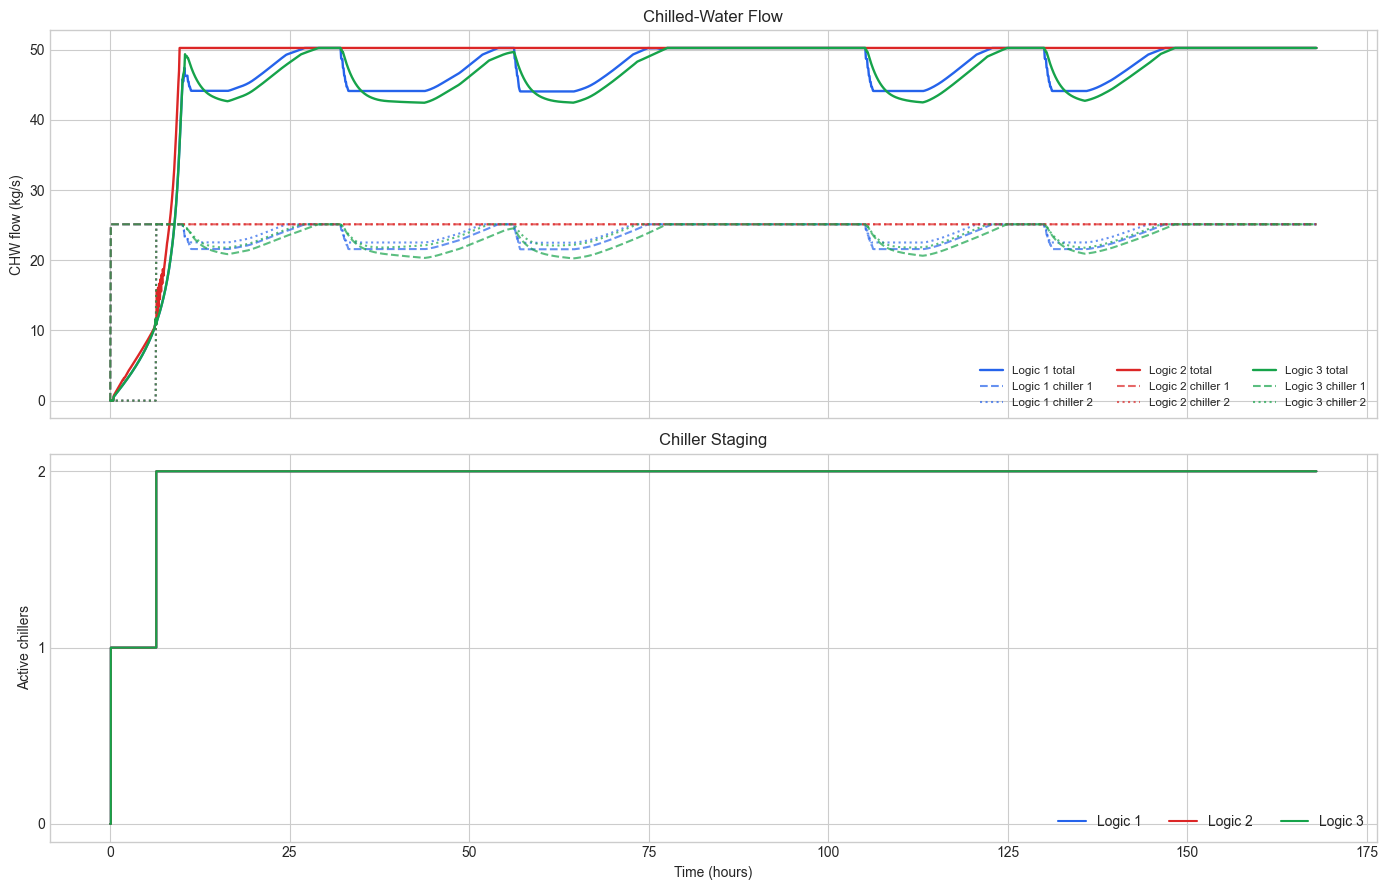

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for label, frame in results_by_logic.items():
    axes[0].plot(frame["hours"], frame["chilled_water_mass_flow_kg_s"], label=f"{label} total", color=COLORS[label], linewidth=1.7)
    axes[0].plot(frame["hours"], frame["chiller_1_mass_flow_kg_s"], label=f"{label} chiller 1", color=COLORS[label], linestyle="--", alpha=0.7)
    axes[0].plot(frame["hours"], frame["chiller_2_mass_flow_kg_s"], label=f"{label} chiller 2", color=COLORS[label], linestyle=":", alpha=0.7)
    axes[1].step(frame["hours"], frame["active_chillers"], where="post", label=label, color=COLORS[label])

axes[0].set_ylabel("CHW flow (kg/s)")
axes[0].set_title("Chilled-Water Flow")
axes[0].legend(ncol=3, fontsize="small")
axes[1].set_xlabel("Time (hours)")
axes[1].set_ylabel("Active chillers")
axes[1].set_yticks([0, 1, 2])
axes[1].set_title("Chiller Staging")
axes[1].legend(ncol=3)
fig.tight_layout()
plt.show()

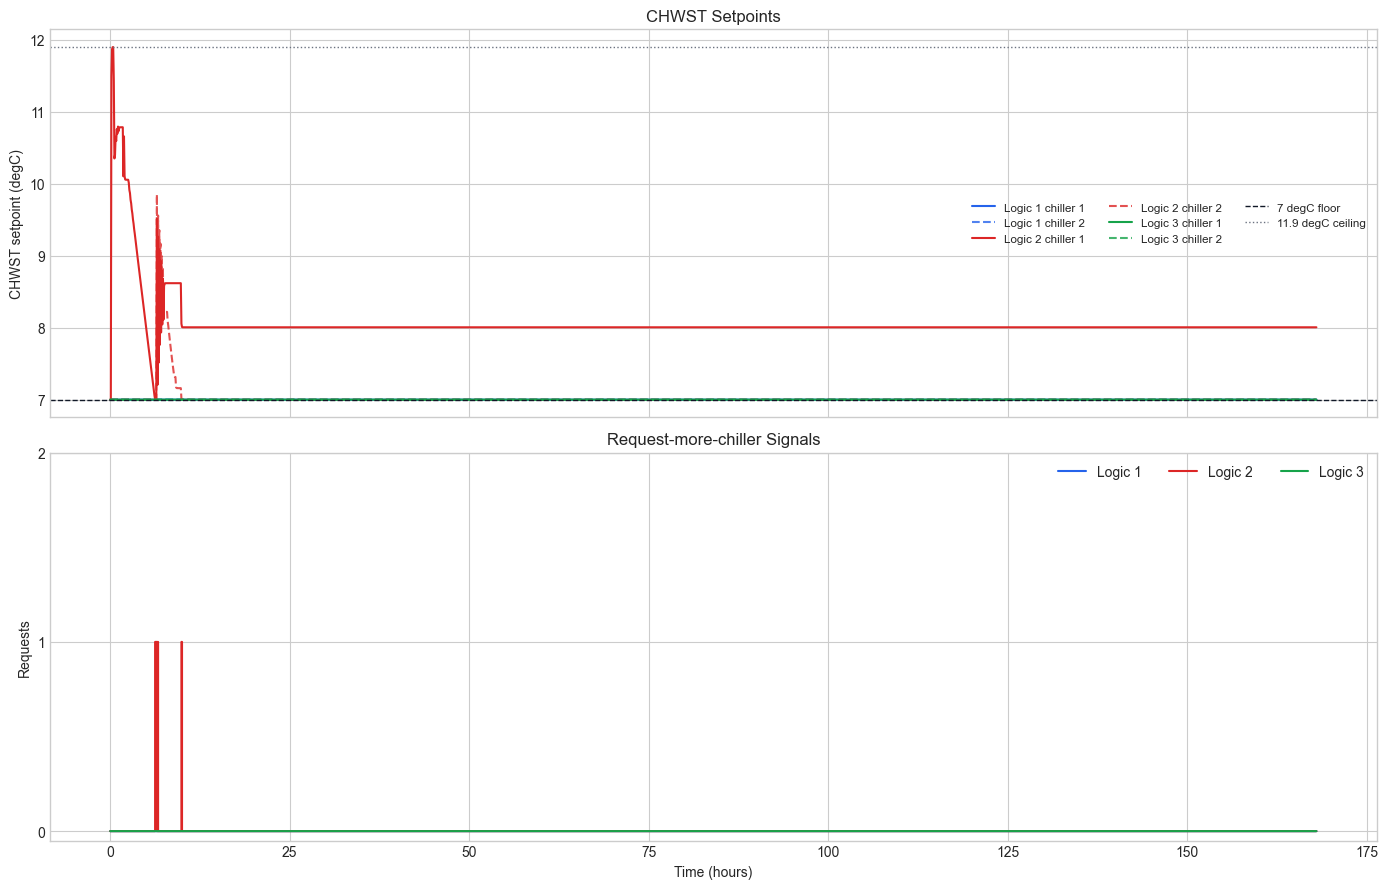

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for label, frame in results_by_logic.items():
    axes[0].plot(frame["hours"], frame["chiller_1_chwst_setpoint_degC"], label=f"{label} chiller 1", color=COLORS[label])
    axes[0].plot(frame["hours"], frame["chiller_2_chwst_setpoint_degC"], label=f"{label} chiller 2", color=COLORS[label], linestyle="--", alpha=0.8)
    axes[1].step(frame["hours"], frame["chiller_1_request_flag"] + frame["chiller_2_request_flag"], where="post", label=label, color=COLORS[label])

axes[0].axhline(7, color="#111827", linestyle="--", linewidth=1, label="7 degC floor")
axes[0].axhline(11.9, color="#6b7280", linestyle=":", linewidth=1, label="11.9 degC ceiling")
axes[0].set_ylabel("CHWST setpoint (degC)")
axes[0].set_title("CHWST Setpoints")
axes[0].legend(ncol=3, fontsize="small")
axes[1].set_xlabel("Time (hours)")
axes[1].set_ylabel("Requests")
axes[1].set_yticks([0, 1, 2])
axes[1].set_title("Request-more-chiller Signals")
axes[1].legend(ncol=3)
fig.tight_layout()
plt.show()